In [1]:
from qiskit.circuit.library import real_amplitudes
from qiskit.circuit import QuantumCircuit, ParameterVector
from utils import ASSETS_DIR
import torch
import torch.nn.functional as F
from models.quantum.quantumMap import QuantumAnsats, VQC
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch.nn as nn
from utils.models import load_all_skops
import torch.optim as optim

La root del progetto è: /home/kirjia/ProgettoQuantumBioetria/src


In [2]:
num_qubits = 6
dim = [4, 8, 16, 32]

dataset = pd.read_csv(ASSETS_DIR / "seeds_11/train_11.csv")
val = pd.read_csv(ASSETS_DIR / "seeds_11/val_11.csv")
X_train = dataset.drop(columns=["label"])
Y_train = dataset["label"]
X_val = val.drop(columns=["label"])
Y_val = val["label"]
scaler = MinMaxScaler(feature_range=(0, 2*np.pi))
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

tensor = torch.from_numpy(X_train).float()
tensor.size()
tensor_Y = torch.from_numpy(Y_train.values).long()

dataset_val = torch.utils.data.TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(Y_val.values).long())
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

objs = load_all_skops(ASSETS_DIR / "seeds_11") 
objs.pop('scaler')


Caricamento di: scaler.skops...
scaler caricato con successo.
Caricamento di: pca_16.skops...
pca_16 caricato con successo.
Caricamento di: pca_4.skops...
pca_4 caricato con successo.
Caricamento di: pca_32.skops...
pca_32 caricato con successo.
Caricamento di: pca_8.skops...
pca_8 caricato con successo.


/tmp/ipykernel_32498/3106240680.py:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor_Y = torch.from_numpy(Y_train.values).long()


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Dimensione originale: 32, Zeri aggiunti: 4, Dimensione padded: 36


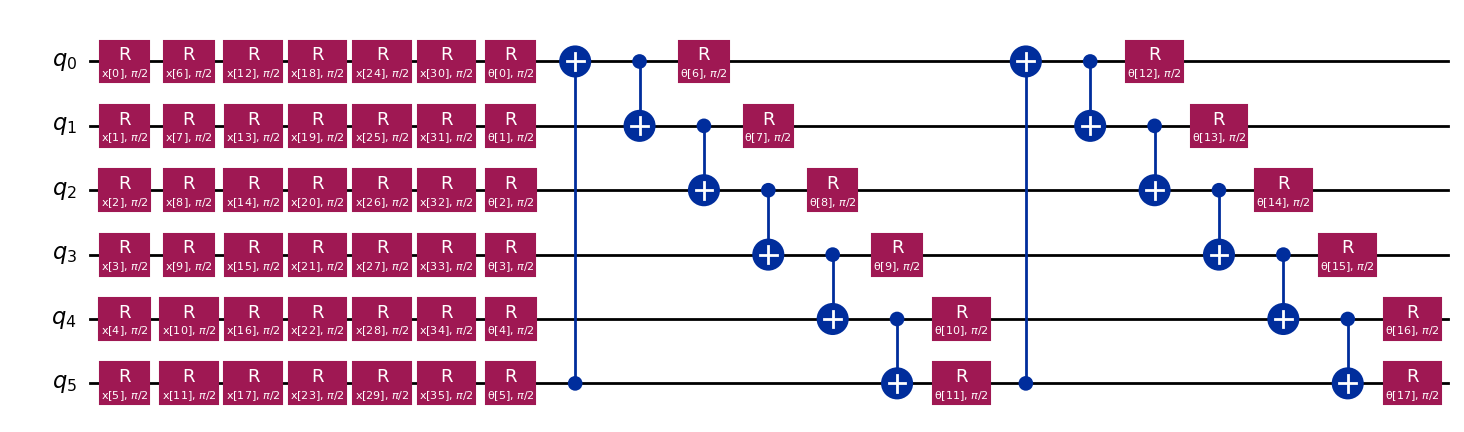

In [3]:
circ = QuantumAnsats(num_qubits, dim[3])
circ.circuit.decompose().draw("mpl")


In [4]:
d_padded = circ.padded_dimension
X_padded = F.pad(tensor, (0, d_padded - dim[3]), mode="constant", value=0.0)
dataset_train = torch.utils.data.TensorDataset(X_padded, tensor_Y)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)


In [11]:
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.gradients import ReverseEstimatorGradient
from qiskit_aer.primitives import EstimatorV2 as AerEstimator


observables = []
for i in range(num_qubits):
    # Mette una 'Z' sul qubit i, e l'identità 'I' su tutti gli altri
    obs = SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=num_qubits)
    observables.append(obs)

#vector_est = StatevectorEstimator()
estimator_gpu = AerEstimator()

# 2. Scateniamo l'Inferno di Silicio (Configurazione NVIDIA)
estimator_gpu.options.simulator = {
    "method": "statevector",  # Simulazione esatta richiesta dal prof
    "device": "GPU",          # Usa la scheda video
    "cuStateVec_enable": True # Attiva i driver quantistici NVIDIA ad alte prestazioni
}
# Nessun rumore, calcolo analitico puro
estimator_gpu.options.default_precision = 0

adjoint_gradient = ReverseEstimatorGradient()

x = circ.parameters

weight_params = [p for p in circ.full_parameters if p not in x]

# 3. Creiamo la QNN
qnn = EstimatorQNN(
    circuit=circ.circuit,          # Il circuito quantistico dell'ansatz
    estimator=estimator_gpu,        # Usa il tuo Estimator v2
    observables=observables,    # I 6 osservabili Pauli-Z
    input_params=x,             # I parametri associati ai dati (batch)
    weight_params=weight_params, # I parametri addestrabili dell'ansatz
    gradient=adjoint_gradient       # Usa il ReverseEstimatorGradient
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
quantum_model = VQC(num_qubits, dim[3], qnn).to(device)

Using device: cuda
Dimensione originale: 32, Zeri aggiunti: 4, Dimensione padded: 36


/home/kirjia/venv-pytorch/lib/python3.12/site-packages/qiskit_machine_learning/connectors/torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


In [12]:
from qiskit_aer import AerSimulator
print("Dispositivi trovati:", AerSimulator().available_devices())

# Creiamo un simulatore base per fare un check
sim = AerSimulator()

# Chiediamo al simulatore quali dispositivi hardware riesce a vedere
print("Dispositivi supportati da questa installazione:", sim.available_devices())

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(quantum_model.parameters(), lr=0.001)
epochs = 10

Dispositivi trovati: ('CPU', 'GPU')
Dispositivi supportati da questa installazione: ('CPU', 'GPU')


In [ ]:
import torch
from torch.profiler import profile, record_function, ProfilerActivity

# Eseguiamo il profiling solo per 1 singolo batch per non rallentare tutto
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=True # Ti dice quale riga di codice consuma tempo
) as prof:
    
    # Prendi solo il primo batch manualmente per il test
    batch_X, batch_y = next(iter(dataloader_train))
    
    with record_function("Trasferimento Dati"):
        batch_X_padded = F.pad(batch_X, (0, circ.padded_dimension - batch_X.size(1)), mode="constant", value=0.0)
        batch_X =   batch_X_padded.to(device)
        batch_y = batch_y.to(device)
        
    with record_function("Forward QNN"):
        logits = quantum_model(batch_X)
        loss = criterion(logits, batch_y)
        
    with record_function("Backward QNN"):
        loss.backward()
        optimizer.step()

# Stampa i risultati nel terminale
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

/home/kirjia/venv-pytorch/lib/python3.12/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


QiskitMachineLearningError: 'Invalid input dimension! Received torch.Size([32, 516]) and expected input compatible to 36'

In [ ]:
import time
# Variabili per l'Early Stopping (come da specifiche del PDF)
best_val_loss = float('inf')
patience = 3
patience_counter = 0

for epoch in range(epochs):
    
    # ==========================================
    # 1. FASE DI TRAINING (Il tuo codice esatto)
    # ==========================================
    quantum_model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in dataloader_train:
        t0 = time.time()
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        
        # Padding dinamico
        batch_X_padded = F.pad(batch_X, (0, circ.padded_dimension - batch_X.size(1)), mode="constant", value=0.0)
        
        logits = quantum_model(batch_X_padded)
        loss = criterion(logits, batch_y)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        t1 = time.time()
        print(f"  Batch processed in {t1 - t0:.2f} seconds")
        
    avg_train_loss = running_loss / len(dataloader_train)
    
    # ==========================================
    # 2. FASE DI VALIDATION
    # ==========================================
    quantum_model.eval() # Mette il modello in modalità valutazione
    val_loss = 0.0
    
    with torch.no_grad(): # Spegne il calcolo dei gradienti (risparmia memoria e tempo)
        for val_X, val_y in dataloader_val:
            
            # Stesso padding dinamico anche per il val_set
            val_X_padded = F.pad(val_X, (0, circ.padded_dimension - val_X.size(1)), mode="constant", value=0.0)
            
            val_logits = quantum_model(val_X_padded)
            loss = criterion(val_logits, val_y)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(dataloader_val)
    
    print(f"Epoca {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # ==========================================
    # 3. CONTROLLO EARLY STOPPING
    # ==========================================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Opzionale ma consigliato: Salva i pesi del modello migliore
        # torch.save(quantum_model.state_dict(), 'best_vqc_model.pth')
    else:
        patience_counter += 1
        print(f"  -> Peggioramento: Patience {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"\n⏹️ Early stopping attivato all'epoca {epoch+1}! Il modello non migliora da {patience} epoche.")
            break # Interrompe il loop delle epoche

  Batch processed in 4.89 seconds


KeyboardInterrupt: 